Verify that the data of your personal project have at least 2 continuous and 2 categorical or discrete variables. 
Otherwise change data.
With your data, proceed to the three analyses you did during the tutorial 1.

Understand data as actual values of random variables; Choose 2 variables of your project and make a probability model of them by assuming that each observation has been obtained by a simple random sampling (i.e. by drawing units uniformly with replacement in the population). Display a frequency table for your variables. Give explicitly the random variables involved and their expression in terms of your sample. What is the joint distribution of the frequencies displayed in the table ? 

The size of the sample, the number of classes and the notations must be clear. 
Proceed to a simple regression with 2 CONTINUOUS variables of your dataset. In this first part, you will write the model with all the assumptions (theoretical results must be written as a markdown), continue with the estimation of parameters, the regression line with all the necessary plots, CI for the prediction and the mean prediction. Outliers and residual analysis must be included. Make a decision about outliers (keep them or erase them from the set). 

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [22]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


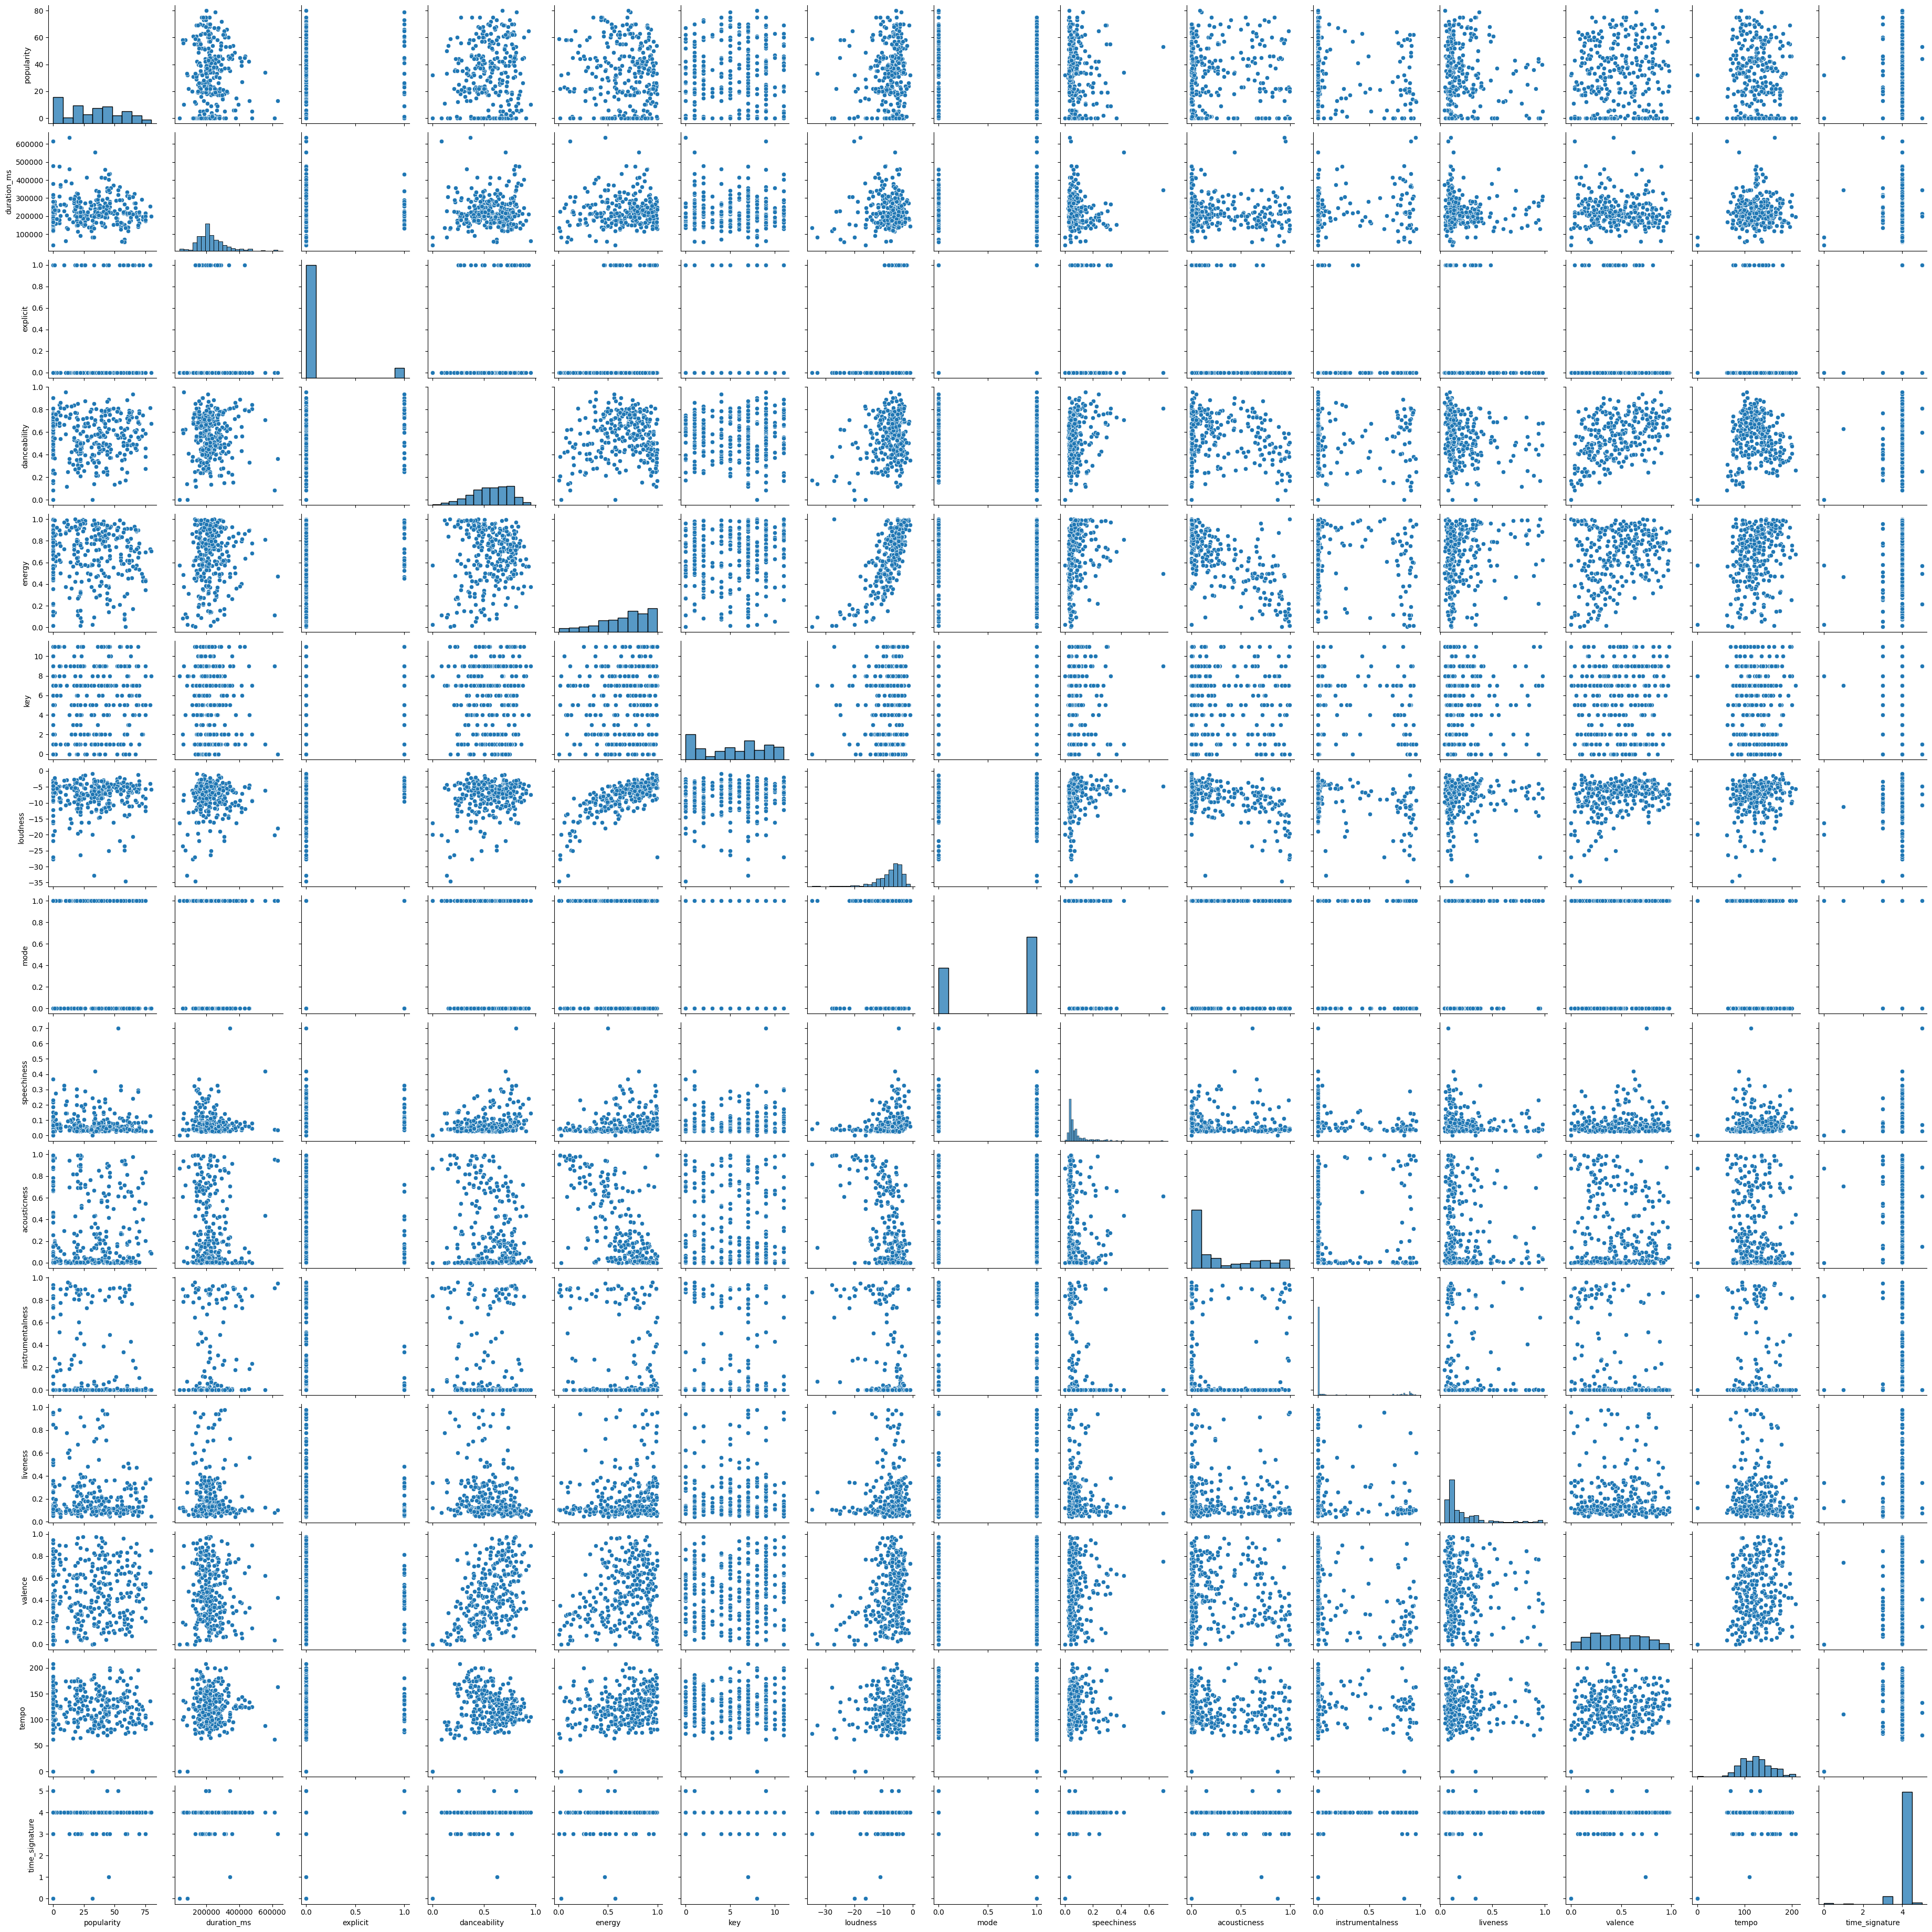

In [ ]:
#sns.pairplot(df.sample(n=300))

In [25]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [26]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=1000) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Bunny Hop Dance Party,Bunny Hop Dance Party,Freeze Dance,0.396,-8.608,0.162000,0,kids
1,Los Prisioneros,Rock un sentimiento vol. I,Estrechez De Corazón,0.742,-8.080,0.001510,11,hard-rock
2,Dolly Parton;Michael Bublé,Merry Christmas,"Cuddle Up, Cozy Down Christmas",0.515,-7.283,0.678000,1,country
3,Camila Cabello;DaBaby,Romance,My Oh My (feat. DaBaby),0.491,-6.024,0.018000,8,dance
4,Brytiago;Darell,Halloween 2022 Perreo Vol. 3,Olvidando,0.672,-4.455,0.120000,2,latin
...,...,...,...,...,...,...,...,...
995,Deafheaven,Sunbather,Dream House,0.804,-4.669,0.000007,7,black-metal
996,CoComelon,"CoComelon Kids Hits, Vol. 2",Helping Song,0.287,-11.912,0.675000,3,children
997,Hillsong Young & Free;TAYA,We Are Young & Free,Wake (Live),0.981,-3.882,0.000154,4,world-music
998,Nenhum De Nós,Histórias Reais Seres Imaginários,Amanhã ou Depois,0.783,-5.695,0.136000,7,mpb


/Users/enzoducros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


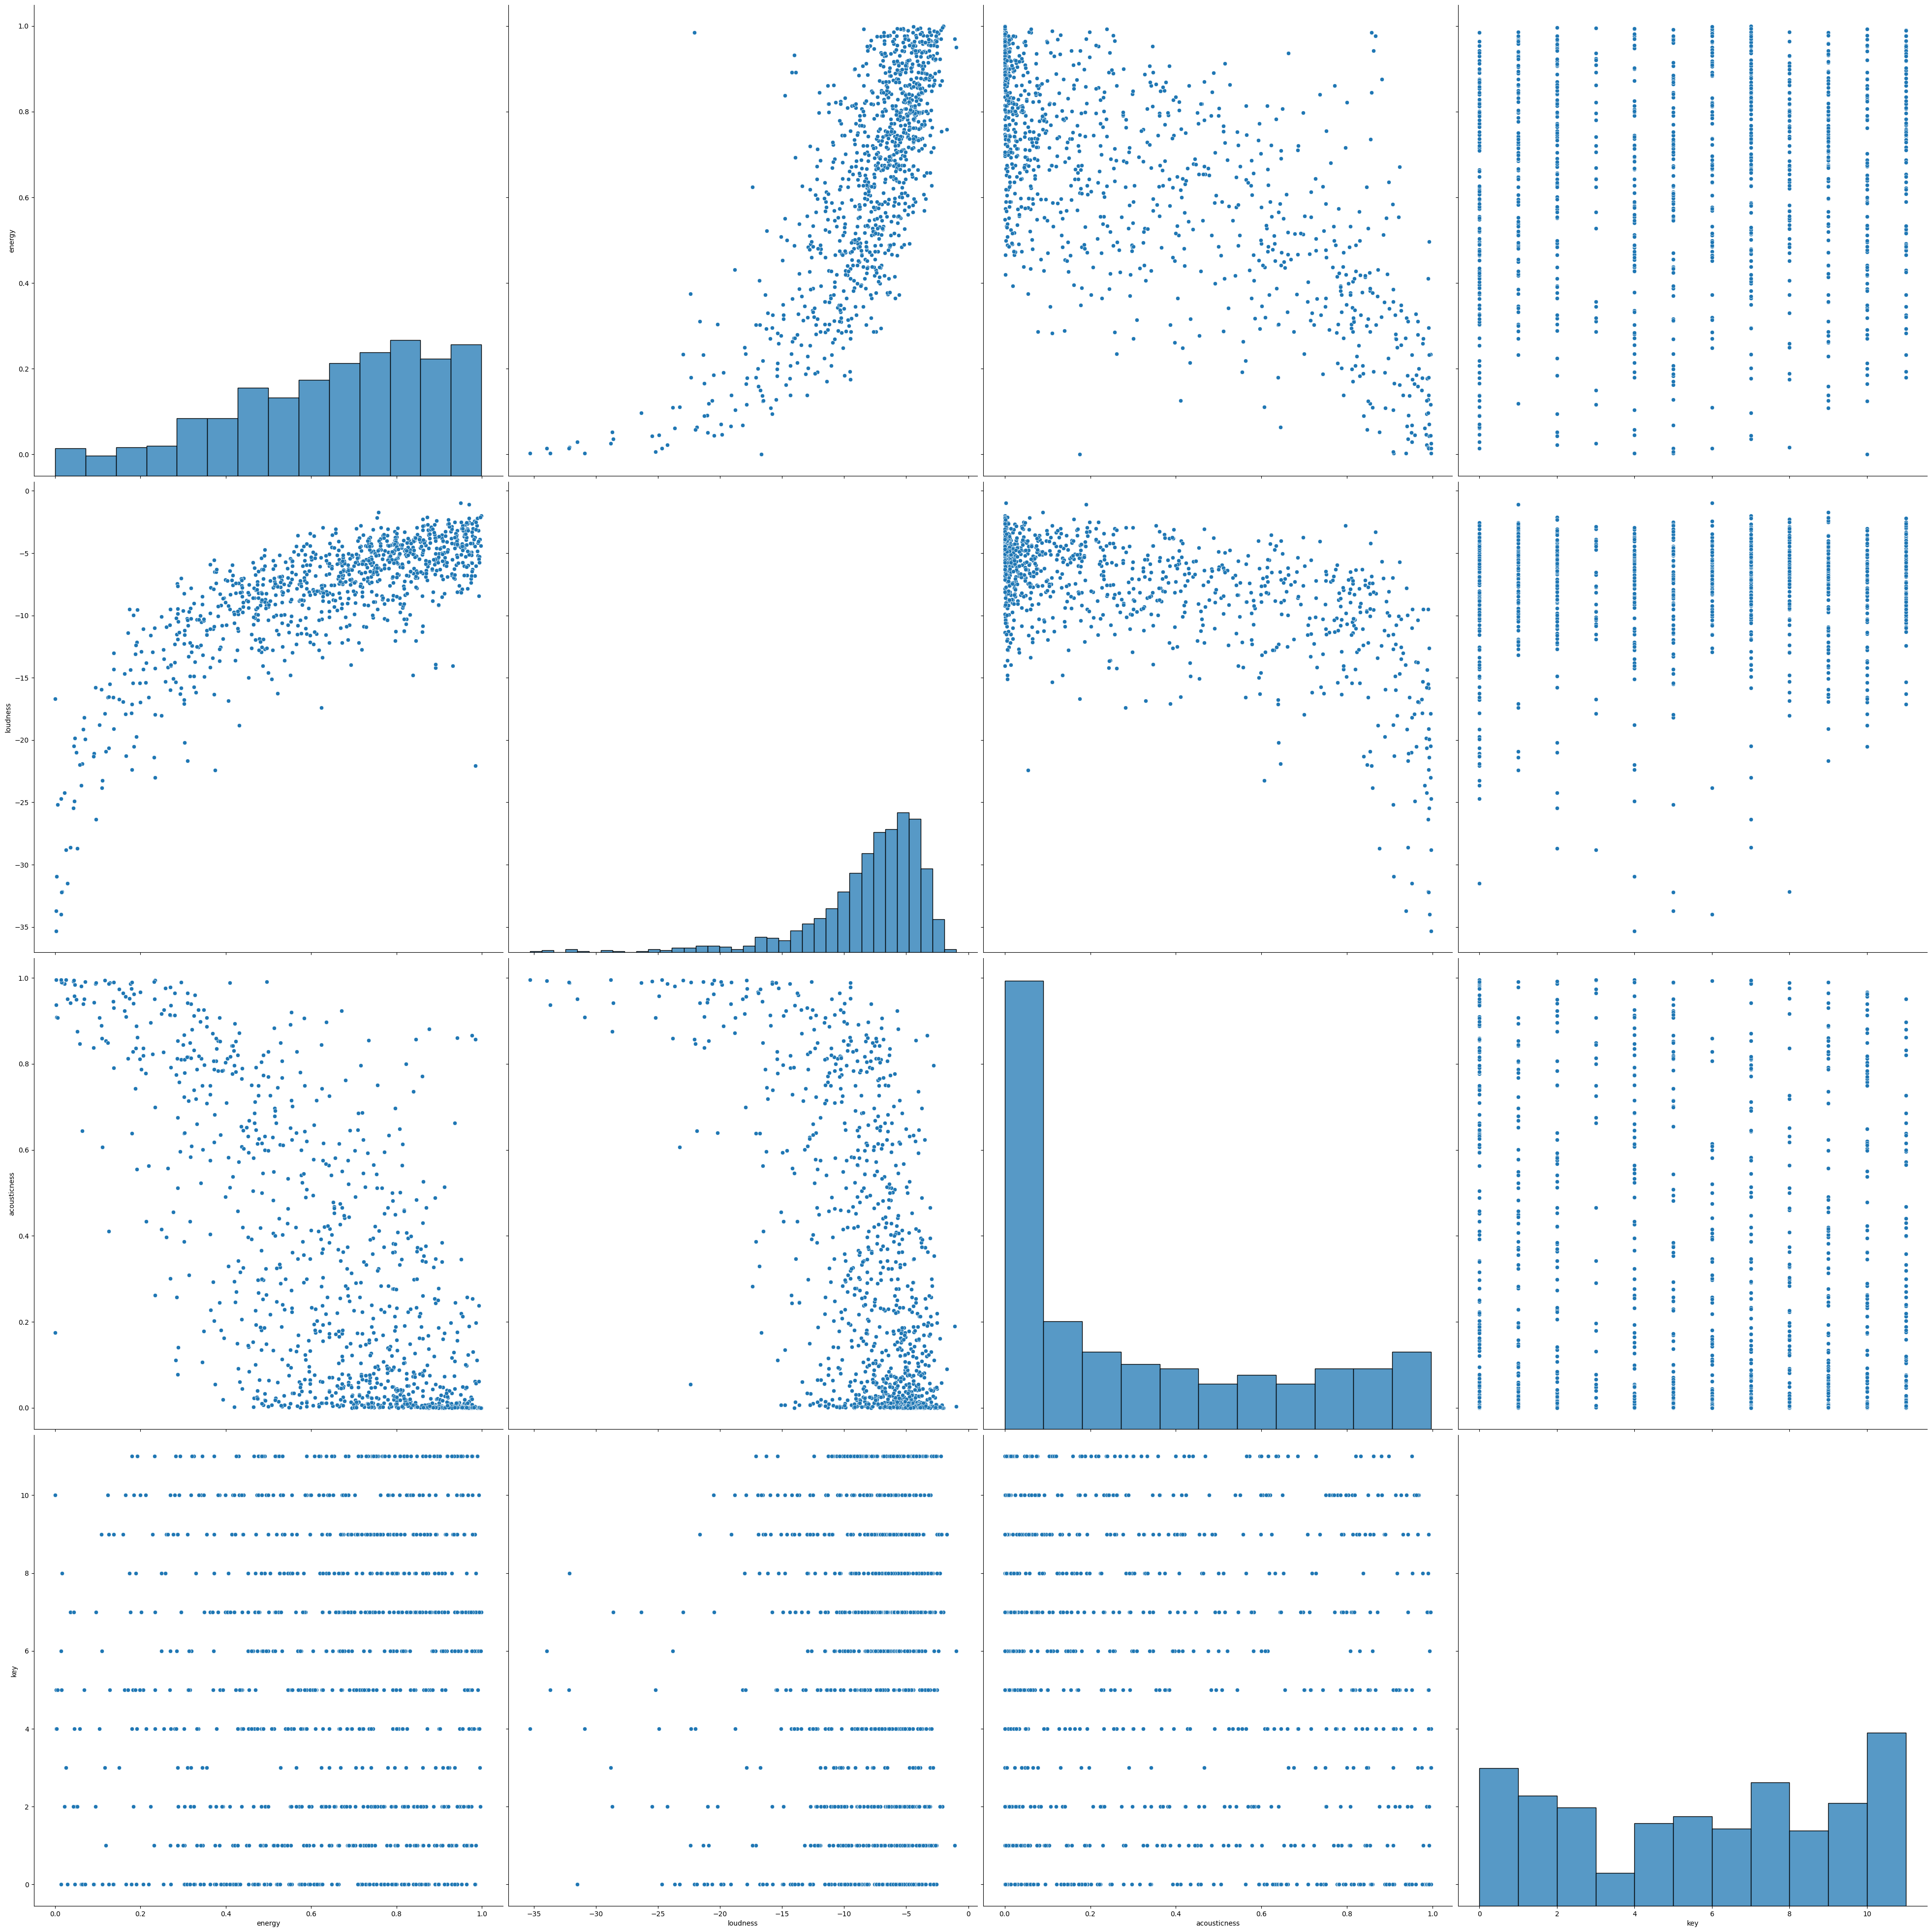

In [46]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

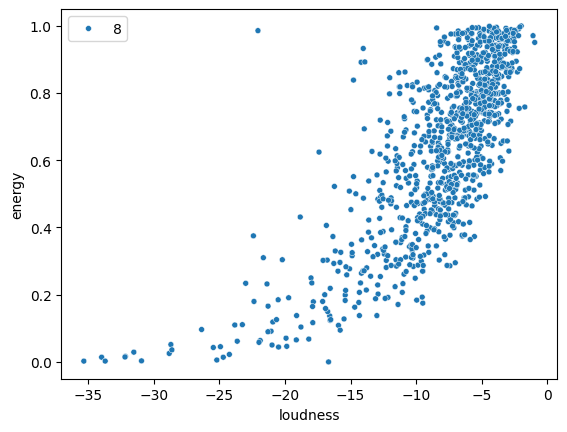

In [ ]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

In [49]:
np.corrcoef(x=spotify_lr.loudness,y=spotify_lr.energy)

array([[1.       , 0.7620638],
       [0.7620638, 1.       ]])

# STOP HERE AND PASS ON BECAUSE LINEARIZATION KILLS THE CORR

**1. Linearisation**

In [40]:
# to linearise , we'll apply a map to the y value
spotify_lr["energy"] = spotify_lr["energy"].map(np.log)
spotify_lr


/var/folders/xl/0wxp8zgx2wz1_sw2nyhksnr00000gn/T/ipykernel_56333/1081503018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spotify_lr["energy"] = spotify_lr["energy"].map(np.log)


,loudness,energy
0,-8.608,-0.926341
1,-8.080,-0.298406
2,-7.283,-0.663588
3,-6.024,-0.711311
4,-4.455,-0.397497
...,...,...
995,-4.669,-0.218156
996,-11.912,-1.248273
997,-3.882,-0.019183
998,-5.695,-0.244623


In [41]:
spotify_lr = spotify_lr.where(spotify_lr > -10)
spotify_lr = spotify_lr.dropna()
spotify_lr

,loudness,energy
0,-8.608,-0.926341
1,-8.080,-0.298406
2,-7.283,-0.663588
3,-6.024,-0.711311
4,-4.455,-0.397497
...,...,...
994,-3.450,-0.130109
995,-4.669,-0.218156
997,-3.882,-0.019183
998,-5.695,-0.244623


array([[1.        , 0.59168928],
       [0.59168928, 1.        ]])

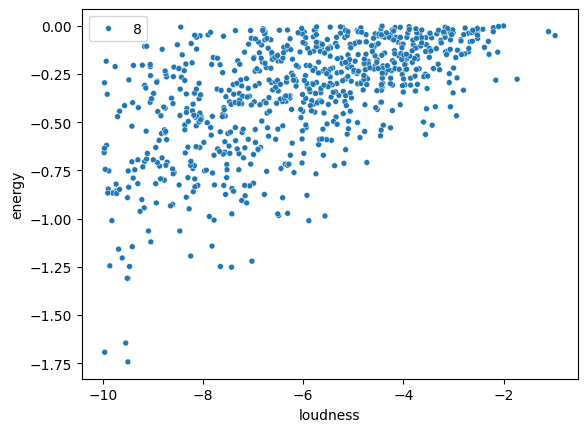

In [42]:
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_lr.energy,spotify_lr.loudness)
# hey , the corr coefficient is 0.8 , it's good 


# CONTINUE HERE

**2. Start of Linear Regression**

In [62]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]
lr

LinregressResult(slope=np.float64(0.0386549313024809), intercept=np.float64(0.9571501703187731), rvalue=np.float64(0.7620637950556266), pvalue=np.float64(1.3758106241418726e-190), stderr=np.float64(0.00103965533157749), intercept_stderr=np.float64(0.009830825413018158))

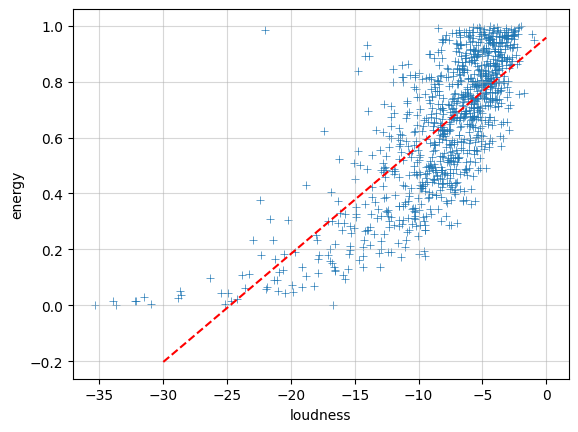

In [70]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)


# Anova regression

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [72]:
spotify



,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,Bunny Hop Dance Party,Bunny Hop Dance Party,Freeze Dance,0.396,-8.608,0.162000,0,kids
1,Los Prisioneros,Rock un sentimiento vol. I,Estrechez De Corazón,0.742,-8.080,0.001510,11,hard-rock
2,Dolly Parton;Michael Bublé,Merry Christmas,"Cuddle Up, Cozy Down Christmas",0.515,-7.283,0.678000,1,country
3,Camila Cabello;DaBaby,Romance,My Oh My (feat. DaBaby),0.491,-6.024,0.018000,8,dance
4,Brytiago;Darell,Halloween 2022 Perreo Vol. 3,Olvidando,0.672,-4.455,0.120000,2,latin
...,...,...,...,...,...,...,...,...
995,Deafheaven,Sunbather,Dream House,0.804,-4.669,0.000007,7,black-metal
996,CoComelon,"CoComelon Kids Hits, Vol. 2",Helping Song,0.287,-11.912,0.675000,3,children
997,Hillsong Young & Free;TAYA,We Are Young & Free,Wake (Live),0.981,-3.882,0.000154,4,world-music
998,Nenhum De Nós,Histórias Reais Seres Imaginários,Amanhã ou Depois,0.783,-5.695,0.136000,7,mpb


In [82]:
types_list = ['house','r-n-b','jazz','brazil','emo','acoustic','latino','drum-and-bass','opera']
spotify_Anova = spotify[spotify['track_genre'].isin(types_list)]
spotify_Anova

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
5,Cali Y El Dandee;Sebastian Yatra,Hora del taco sin auto,Locura,0.778,-3.562,0.0806,8,latino
17,Dean Martin,Best Christmas Songs 2022 | For under the Mist...,Let It Snow! Let It Snow! Let It Snow!,0.332,-10.312,0.7870,1,jazz
72,Sensey;Sergei Barracuda,BRATAN,Policie zná moje jméno,0.803,-5.819,0.4080,8,emo
93,Logistics;Ownglow;Prizm,NHS300,Flutterbyes,0.884,-6.332,0.0013,6,drum-and-bass
103,Ella Fitzgerald,pov: you are an christmas elf,Hotta Chocolatta,0.532,-6.854,0.7680,1,jazz
...,...,...,...,...,...,...,...,...
901,Josh A,OUT THE GRAVE,OUT THE GRAVE,0.738,-6.455,0.1220,8,emo
903,Lalo Ebratt;Trapical,Fiesta portatil,Boomerang,0.661,-5.857,0.2210,0,latino
910,Feid,Esto No Se Le Dedica A Cualquiera,AMOR DE MI VIDA,0.674,-5.629,0.1800,6,latino
950,"Sergio Vega ""El Shaka""",El Jefe De Las Plazas,El Jefe De Las Plazas,0.600,-5.323,0.4130,10,r-n-b


In [83]:
spotify_Anova = spotify_Anova[['track_genre','energy']]
spotify_Anova

,track_genre,energy
5,latino,0.778
17,jazz,0.332
72,emo,0.803
93,drum-and-bass,0.884
103,jazz,0.532
...,...,...
901,emo,0.738
903,latino,0.661
910,latino,0.674
950,r-n-b,0.600


<Axes: xlabel='track_genre', ylabel='energy'>

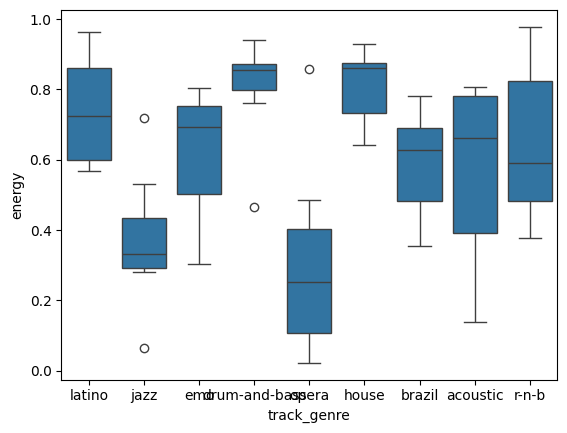

In [86]:

sns.boxplot(data=spotify_Anova, x='track_genre', y='energy')

Hey , there seems to be a good difference in between types  , and also some that maybe are very similar ( for example drum&Bass and house that are very similar in style so it's not suprising that they have similar boxplots )